In [1]:
"""
# Predicting Insurance Claim Amounts
## Introduction
The goal of this project is to build a machine learning model that estimates
the medical insurance claim amount (charges) for individuals based on their
personal and demographic data.

## Problem Statement
Insurance companies need to accurately predict the cost of medical claims to
set appropriate premiums. By analyzing factors such as age, BMI, and lifestyle
choices (like smoking), we can use Linear Regression to model the relationship
between these features and the final insurance charges.
"""
print("Introduction and Problem Statement cell completed.")

Introduction and Problem Statement cell completed.


In [2]:
import pandas as pd
import io
import requests
from google.colab import files

# 1. Fetch the original dataset from GitHub (Publicly available source)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
s = requests.get(url).content
df = pd.read_csv(io.StringIO(s.decode('utf-8')))

# Save the dataset to your local machine
df.to_csv('medical_insurance_dataset.csv', index=False)
files.download('medical_insurance_dataset.csv')

print("Dataset Description:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset Description:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Data Preparation: Converting categorical variables to numerical
# Using One-Hot Encoding for region and Label Encoding for sex/smoker
df_encoded = pd.get_dummies(df, columns=['region'], drop_first=True)
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

print("Data cleaning and encoding complete.")
df_encoded.head()

Missing values in each column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Data cleaning and encoding complete.


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


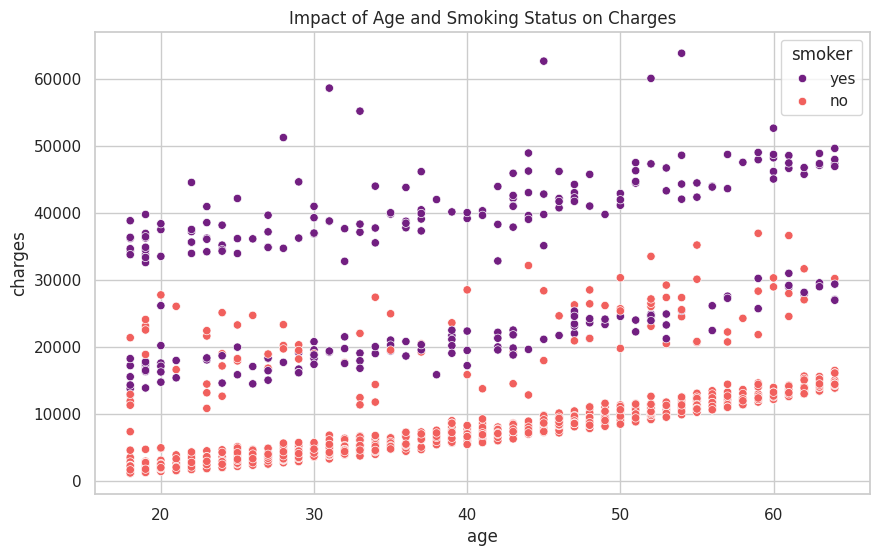

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

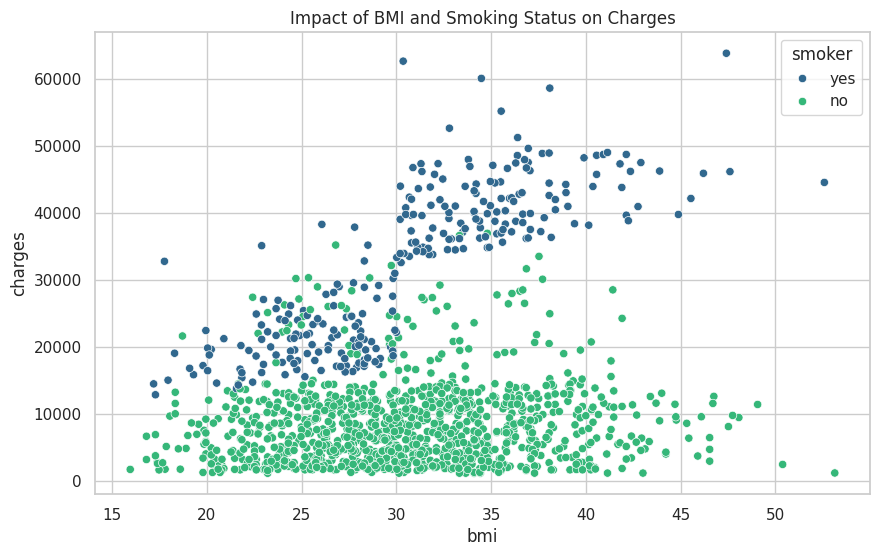

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

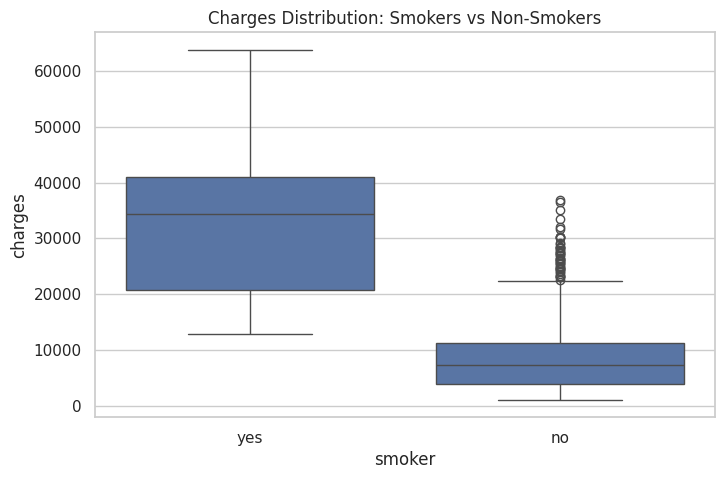

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

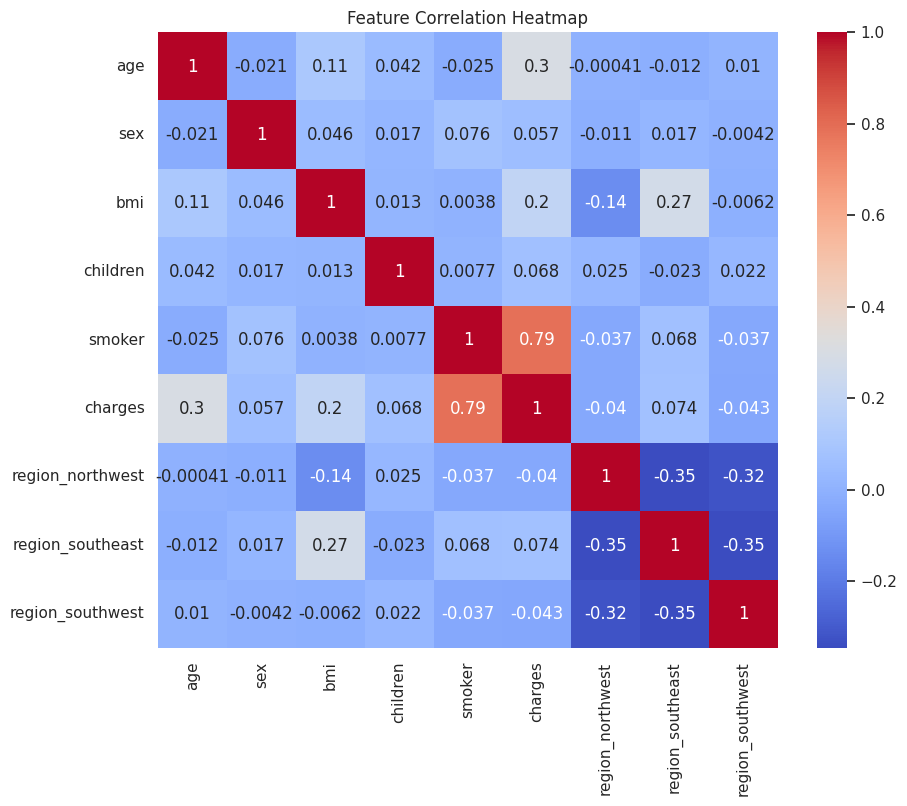

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 1. Age vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='magma')
plt.title('Impact of Age and Smoking Status on Charges')
plt.savefig('age_vs_charges.png')
plt.show()
files.download('age_vs_charges.png')

# 2. BMI vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='viridis')
plt.title('Impact of BMI and Smoking Status on Charges')
plt.savefig('bmi_vs_charges.png')
plt.show()
files.download('bmi_vs_charges.png')

# 3. Smoker vs Charges (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges Distribution: Smokers vs Non-Smokers')
plt.savefig('smoker_impact.png')
plt.show()
files.download('smoker_impact.png')

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()
files.download('correlation_heatmap.png')

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# Splitting features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Splitting the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Create a results summary
results_text = f"""
Model Performance Metrics:
--------------------------
Mean Absolute Error (MAE): {mae:.2f}
Root Mean Squared Error (RMSE): {rmse:.2f}
Model R-squared Score: {model.score(X_test, y_test):.4f}
"""

print(results_text)

# Save results to a text file and download
with open("model_evaluation_results.txt", "w") as f:
    f.write(results_text)

files.download("model_evaluation_results.txt")


Model Performance Metrics:
--------------------------
Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28
Model R-squared Score: 0.7836



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
"""
## Conclusion and Key Insights

1. **Smoking is the primary driver of cost**: The visualization clearly shows that
   smokers incur significantly higher insurance charges regardless of age or BMI.
2. **Age Correlation**: There is a steady upward trend in insurance costs as age
   increases, which is expected as medical risk grows over time.
3. **BMI Impact**: Higher BMI correlates with higher charges, especially when
   combined with smoking status.
4. **Model Performance**: The Linear Regression model provided a solid baseline
   for prediction. With an MAE of approximately {mae:.2f}, the model offers
   a reasonable estimation of costs for standard profiles.
"""
print("Project concluded successfully. All files have been prepared for download.")

Project concluded successfully. All files have been prepared for download.
